In [3]:
import pandas as pd
orders = pd.read_csv("../data/processed/clean_orders.csv")

In [5]:
orders['order_placed_at'] = pd.to_datetime(orders['order_placed_at'])
orders['order_hour'] = orders['order_placed_at'].dt.hour
orders['order_day'] = orders['order_placed_at'].dt.day_name()
orders['is_weekend'] = orders['order_day'].isin(['Saturday','Sunday'])

In [6]:
orders[['order_placed_at','order_hour','order_day','is_weekend']].head()

,order_placed_at,order_hour,order_day,is_weekend
0,2024-09-10 23:38:00,23,Tuesday,False
1,2024-09-10 23:34:00,23,Tuesday,False
2,2024-09-10 15:52:00,15,Tuesday,False
3,2024-09-10 15:45:00,15,Tuesday,False
4,2024-09-10 15:04:00,15,Tuesday,False


In [7]:
orders_per_hour = orders.groupby('order_hour')['order_id'].count().reset_index()
orders_per_hour = orders_per_hour.rename(columns={'order_id':'order_count'})

orders_per_hour.sort_values('order_count', ascending=False).head()

,order_hour,order_count
14,20,2912
13,19,2419
15,21,2296
16,22,1748
12,18,1611


In [8]:
orders_per_hour['hour_label'] = pd.to_datetime(orders_per_hour['order_hour'], format='%H').dt.strftime('%I %p')
orders_per_hour = orders_per_hour.sort_values('order_hour')

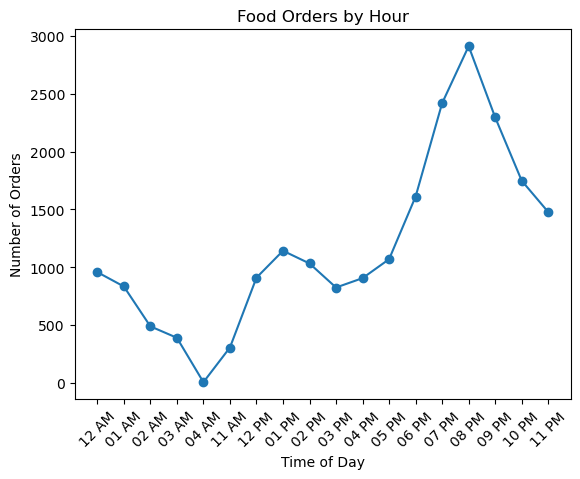

In [9]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(
    orders_per_hour['hour_label'],
    orders_per_hour['order_count'],
    marker='o'
)

plt.xlabel("Time of Day")
plt.ylabel("Number of Orders")
plt.title("Food Orders by Hour")

plt.xticks(rotation=45)

plt.show()

In [10]:
orders_per_day = (
    orders.groupby('order_day')['order_id']
    .count()
    .reset_index()
    .rename(columns={'order_id': 'order_count'})
)

orders_per_day

,order_day,order_count
0,Friday,3403
1,Monday,2196
2,Saturday,3923
3,Sunday,2958
4,Thursday,2879
5,Tuesday,2885
6,Wednesday,3077


In [11]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

orders_per_day['order_day'] = pd.Categorical(
    orders_per_day['order_day'],
    categories=day_order,
    ordered=True
)

In [13]:
orders_per_day = orders_per_day.sort_values('order_count', ascending=False)
day_order_sorted = orders_per_day['order_day']

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8932\2290260249.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


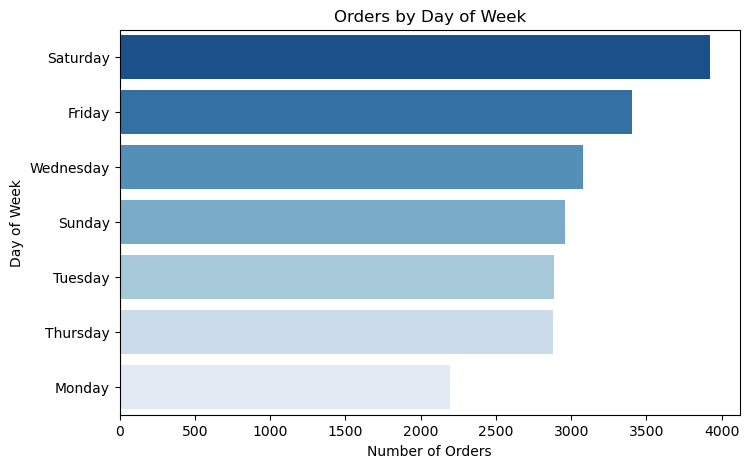

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=orders_per_day,
    x='order_count',
    y='order_day',
    order=day_order_sorted,
    palette=sns.color_palette("Blues_r", len(orders_per_day))
)

plt.xlabel("Number of Orders")
plt.ylabel("Day of Week")
plt.title("Orders by Day of Week")

plt.show()

In [15]:
orders_per_day.to_csv("../data/processed/orders_by_day.csv", index=False)

In [16]:
orders_per_hour.to_csv("../data/processed/orders_by_hour.csv", index=False)